In [20]:
import keras
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix



In [2]:
model = keras.models.load_model("efficientnetb0_v1.keras")

In [7]:
ROOT = Path.cwd()
IMAGE_DIR = ROOT / "data" / "stress_test" / "images"
if not IMAGE_DIR.is_dir():
    raise FileNotFoundError(
        f"Missing {IMAGE_DIR}. cd to the repo root or fix IMAGE_DIR."
    )
# Split the data into train, val and test
batch_size = 32
seed = 1337
# Load 80% of the data for training
full_ds = keras.utils.image_dataset_from_directory(
    IMAGE_DIR,
    seed=seed,
    shuffle=True,
    image_size=(224, 224),
    batch_size=None
)
test_ds = full_ds.batch(batch_size)


Found 531 files belonging to 2 classes.


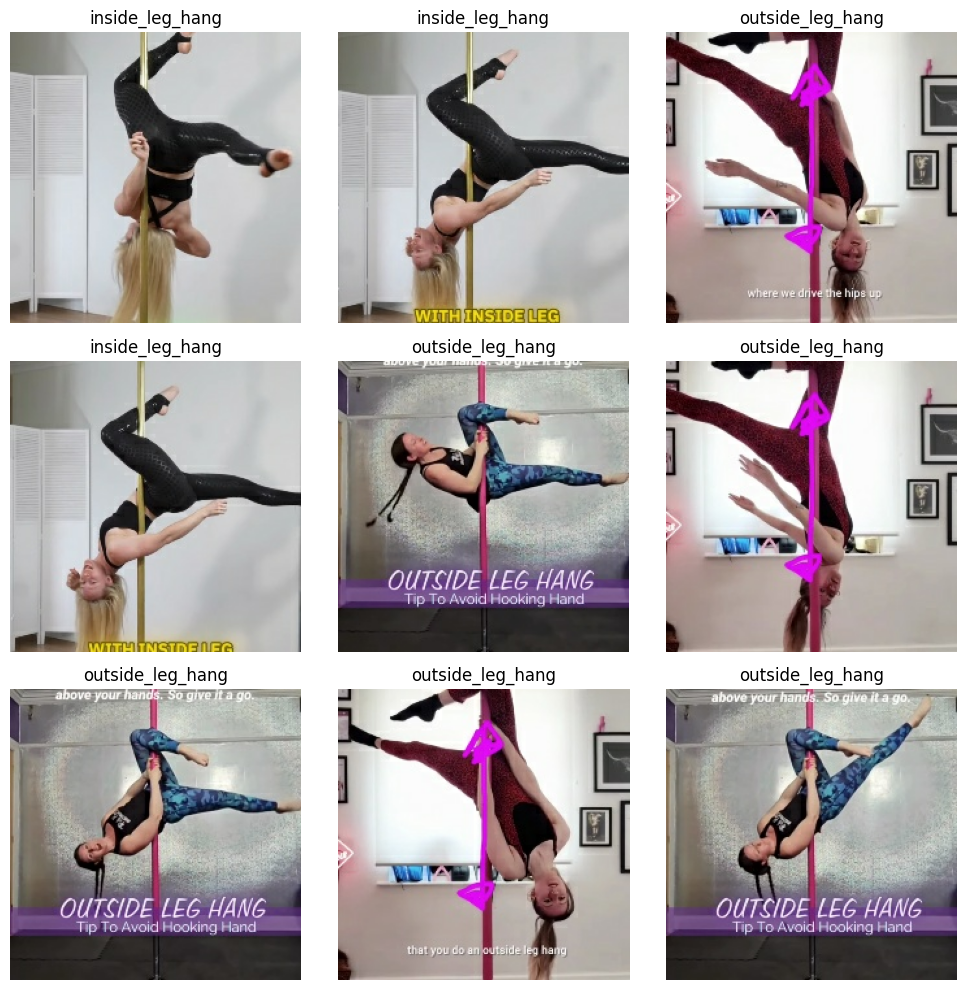

In [17]:
class_names = full_ds.class_names
plt.figure(figsize=(10, 10))
for images, labels in test_ds.take(1):
    n = min(9, int(images.shape[0]))
    for i in range(n):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(images[i]).astype("uint8"))
        lbl = int(labels[i])
        title = class_names[lbl] if lbl < len(class_names) else str(lbl)
        plt.title(title)
        plt.axis("off")
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step


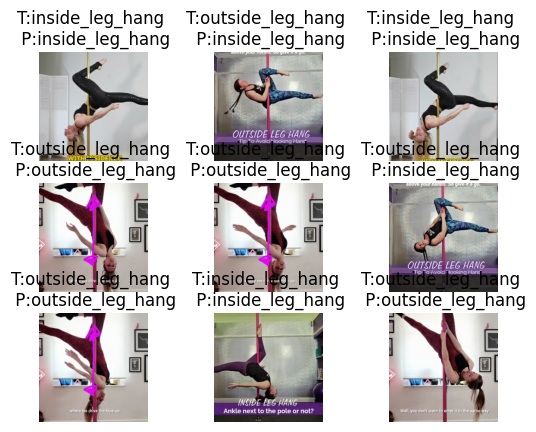

In [12]:
# Assuming 'model' is trained and 'test_dataset' is ready

class_names = full_ds.class_names
for images, labels in test_ds.take(1):
    preds = model.predict(images)
    for i in range(9): # Display 9 images
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(f"T:{class_names[int(labels[i])]} \n P:{class_names[int(np.argmax(preds[i]))]}")
        plt.axis("off")
plt.show()

In [13]:
y_true, y_pred = [], []
mis = []
for images, labels in test_ds:
    probs = model.predict(images, verbose=0)
    pred = np.argmax(probs, axis=-1)
    y_true.extend(labels.numpy().tolist())
    y_pred.extend(pred.tolist())
    for i in range(len(labels)):
        yt, yp = int(labels[i]), int(pred[i])
        if yt != yp:
            mis.append((images[i].numpy(), yt, yp))

y_true = np.array(y_true)
y_pred = np.array(y_pred)
print(f"misclassified: {np.sum(y_true != y_pred)} / {len(y_true)}")

misclassified: 151 / 531


In [21]:
print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, target_names=class_names, digits=3))


[[184  93]
 [ 58 196]]
                  precision    recall  f1-score   support

 inside_leg_hang      0.760     0.664     0.709       277
outside_leg_hang      0.678     0.772     0.722       254

        accuracy                          0.716       531
       macro avg      0.719     0.718     0.715       531
    weighted avg      0.721     0.716     0.715       531



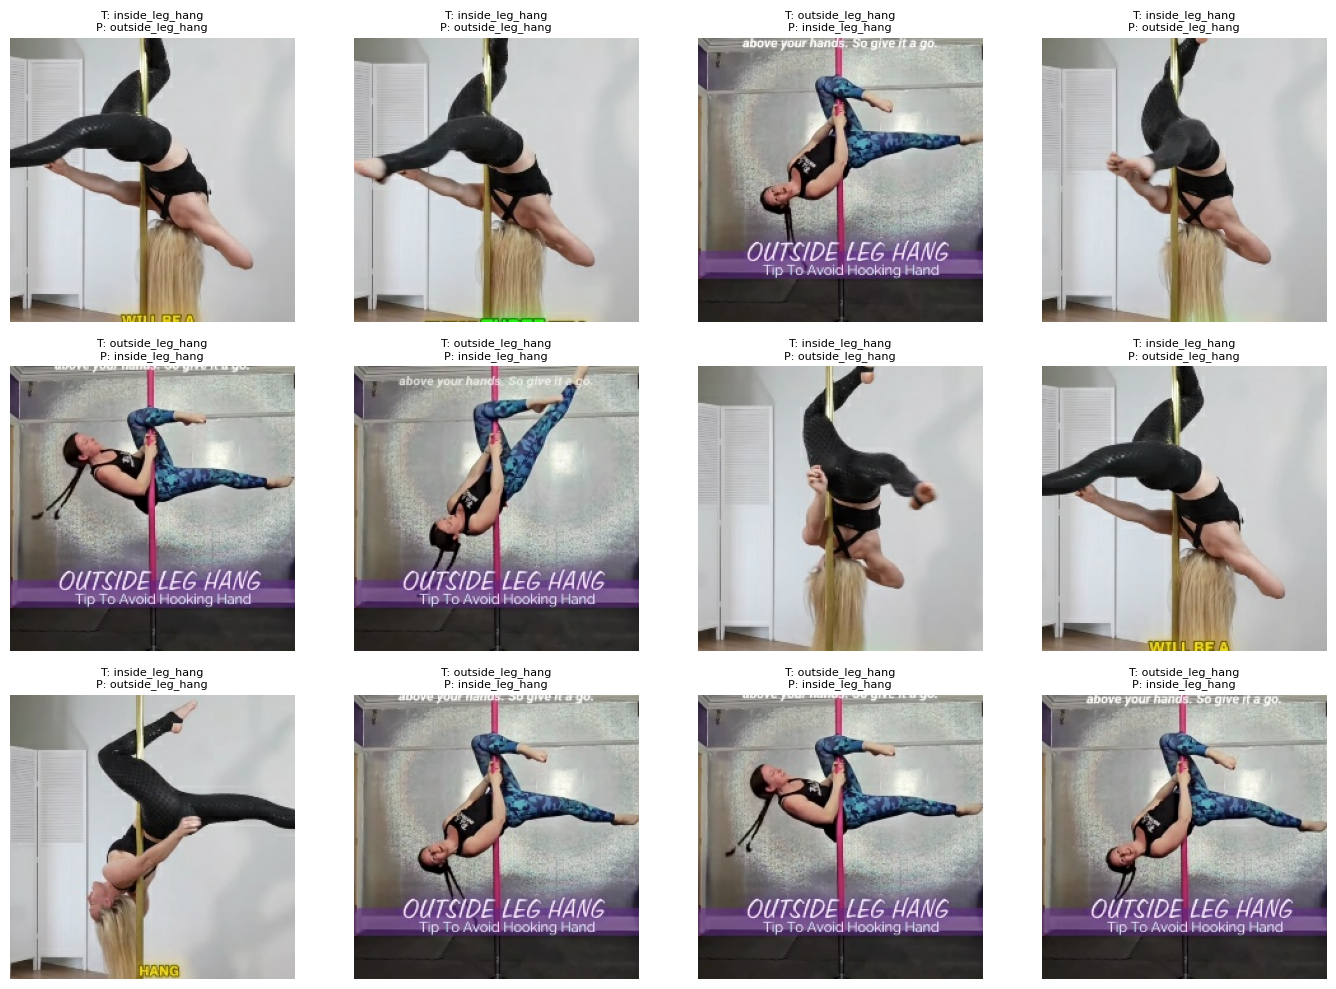

In [25]:
n = min(12, len(mis))
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
for ax, (img, yt, yp) in zip(axes.flat, mis[:n]):
    ax.imshow(img.astype("uint8"))
    ax.set_title(
        f"T: {class_names[yt]}\nP: {class_names[yp]}",
        fontsize=8,
    )
    ax.axis("off")
for j in range(n, 12):
    axes.flat[j].axis("off")
plt.tight_layout()
plt.show()
